# Customer Churn & Revenue Retention Analytics  
## Executive Decision Support Case Study  


### Executive Business Question  
**Where is revenue leaking due to customer churn, and which customer signals indicate the highest preventable financial risk?**

### Project Overview  
This project quantifies **monthly revenue at risk caused by customer churn** and identifies **high-impact customer segments requiring proactive retention intervention**.

Rather than treating churn as a binary outcome, the analysis introduces a **lifecycle- and risk-based framework** that connects customer behavior, contract structure, and revenue exposure.

### Data Strategy  
- **IBM Telco Customer Churn Dataset** — source of financial, contract, and behavioral truth  
- **Comcast Telecom Complaints Dataset (Kaggle)** — qualitative *Voice of Customer* context explaining *why* high-risk customers disengage

📌 Complaints are analyzed as **directional sentiment signals** and are intentionally not joined to subscription records to avoid false causality.

## ENVIRONMENT SETUP

In [ ]:
# =============================================================
# GLOBAL CONFIGURATION & ENVIRONMENT SETUP
# =============================================================

# 1. Standard Library & Environment Utilities
import gc
import csv
import warnings
from google.colab import files

# 2. Core Data Manipulation
import pandas as pd
import numpy as np

# 3. Visualization Architecture
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Machine Learning: Preprocessing & Pipelines
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# 5. Machine Learning: Modeling & Metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# --- Global Configurations ---

# Styling: Clean, professional aesthetic for executive reports
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

# Suppress non-critical warnings for a cleaner notebook presentation
warnings.filterwarnings('ignore')

# Constants: Defined for automated export/import workflows
EXPORT_FILES = ['dim_customer.csv', 'fact_subscription.csv', 'fact_feedback.csv']

print("✅ Environment successfully configured and dependencies loaded.")

✅ Environment successfully configured and dependencies loaded.


## DATA UNDERSTANDING (NO TRANSFORMATIONS)

**Purpose:** Audit raw data integrity to identify structural issues that could distort financial KPIs, churn rates, or revenue calculations downstream.

**Data Loading**

In [ ]:
# =============================================================
# DATA INGESTION: MULTI-SOURCE ACQUISITION
# =============================================================

# Triggering the manual upload interface for session files
uploaded = files.upload()

# 1. Load Subscription Data (Structured CSV)
churn_raw = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# 2. Load Customer Feedback (Unstructured/Qualitative CSV)
# 'utf-8-sig' handles the Byte Order Mark (BOM) common in Excel/Export files
feedback_raw = pd.read_csv("Comcast_telecom_complaints_data.csv", encoding='utf-8-sig')

# 3. TECHNICAL VERIFICATION: INITIAL DATA SNAPSHOTS
# We display both to confirm successful ingestion of financial and text data
print("--- [01] Subscription Data Preview ---")
print(f"Total Records: {len(churn_raw)}")
display(churn_raw.head(3))

print("\n--- [02] Customer Feedback Preview ---")
print(f"Total Records: {len(feedback_raw)}")
display(feedback_raw.head(3))

Saving Comcast_telecom_complaints_data.csv to Comcast_telecom_complaints_data.csv
Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv
--- [01] Subscription Data Preview ---
Total Records: 7043


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes



--- [02] Customer Feedback Preview ---
Total Records: 2224


,Ticket #,Customer Complaint,Date,Date_month_year,Time,Received Via,City,State,Zip code,Status,Filing on Behalf of Someone
0,250635,Comcast Cable Internet Speeds,22-04-15,22-Apr-15,3:53:50 PM,Customer Care Call,Abingdon,Maryland,21009,Closed,No
1,223441,Payment disappear - service got disconnected,04-08-15,04-Aug-15,10:22:56 AM,Internet,Acworth,Georgia,30102,Closed,No
2,242732,Speed and Service,18-04-15,18-Apr-15,9:55:47 AM,Internet,Acworth,Georgia,30101,Closed,Yes


**Initial Data Inspection**

In [ ]:
print("--- Dataset Integrity Audit ---")
print(f"Churn Records: {churn_raw.shape[0]} | Feedback Records: {feedback_raw.shape[0]}")
print(f"Duplicate Rows (Churn): {churn_raw.duplicated().sum()}")


--- Dataset Integrity Audit ---
Churn Records: 7043 | Feedback Records: 2224
Duplicate Rows (Churn): 0


**Data Quality Audit**

In [ ]:
# =============================================================
# DATA QUALITY AUDIT: INTEGRITY & DISTRIBUTION CHECK
# =============================================================

print("----- DUPLICATE & UNIQUE ID CHECK -----")
# Verifying unique primary keys to ensure no 'Fan-out' during future joins
print(f"Total Duplicate Rows (Churn): {churn_raw.duplicated().sum()}")
print(f"Total Duplicate Rows (Feedback): {feedback_raw.duplicated().sum()}")
print(f"Unique Customer IDs: {churn_raw['customerID'].nunique()} (Total: {len(churn_raw)})")

print("\n----- NUMERIC DISTRIBUTION SUMMARY -----")
# High-level statistical check for Monthly Charges and Tenure
# This identifies potential outliers or negative values before cleaning
display(churn_raw[["MonthlyCharges", "tenure"]].describe().round(2))

print("\n----- CATEGORICAL DATA EXPLORATION -----")
# Automated scan of categorical columns with low cardinality
# This identifies hidden "Unknown" or "N/A" strings in the categories
for col in churn_raw.select_dtypes(include="object").columns:
    if churn_raw[col].nunique() < 10:
        print(f"\nValue Counts for {col}:")
        print(churn_raw[col].value_counts())

----- DUPLICATE & UNIQUE ID CHECK -----
Total Duplicate Rows (Churn): 0
Total Duplicate Rows (Feedback): 0
Unique Customer IDs: 7043 (Total: 7043)

----- NUMERIC DISTRIBUTION SUMMARY -----


,MonthlyCharges,tenure
count,7043.00,7043.00
mean,64.76,32.37
std,30.09,24.56
min,18.25,0.00
25%,35.50,9.00
50%,70.35,29.00
75%,89.85,55.00
max,118.75,72.00



----- CATEGORICAL DATA EXPLORATION -----

Value Counts for gender:
gender
Male      3555
Female    3488
Name: count, dtype: int64

Value Counts for Partner:
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Value Counts for Dependents:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

Value Counts for PhoneService:
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

Value Counts for MultipleLines:
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

Value Counts for InternetService:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Value Counts for OnlineSecurity:
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

Value Counts for OnlineBackup:
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

### Insight - Data Quality

The data is **structurally complete and internally consistent**.  
Minor gaps in `TotalCharges` align with **tenure = 0**, indicating new customer onboarding rather than data loss.

📌 These records are preserved to maintain **accurate acquisition metrics and first-month revenue reporting**.

## ETL & DATA CLEANING (STAGING LAYER)

This phase standardizes raw data into **analysis-ready structures** while preserving original business meaning and financial accuracy.

All transformations are:
- Explicitly justified by downstream KPIs
- Designed for SQL and BI consumption
- Fully reversible to protect auditability

**Business Question:**  
How can we simplify customer attributes to make churn risk segments more interpretable and actionable?

**Purpose:**  
This cleaning step is **not designed to improve model performance**, but to ensure all downstream KPIs remain **accurate, interpretable, and business-consistent**.

**Feedback Data Cleaning & Alignment Fix**

### Why We Clean the Feedback Dataset

Customer complaint data is used as **qualitative context**, not transactional truth.

Cleaning focuses on:
- Preventing CSV corruption
- Ensuring SQL and Power BI compatibility
- Preserving original customer language without semantic reinterpretation

📌 No sentiment scoring or causal inference is introduced at this stage.

In [ ]:
# 1. Column Header Normalization (SQL-Friendly naming)
feedback = feedback_raw.copy()
feedback.columns = (feedback.columns
                    .str.replace("Ticket #", "Ticket")
                    .str.strip()
                    .str.replace(" ", "_")
                    .str.replace("__", "_"))

# 2. String Sanitization
# Prevents CSV delimiter corruption by cleaning semicolons and line breaks
feedback = feedback.replace({';': ' -', r'\r+|\n+': ' '}, regex=True)

# 3. Datetime Standardization (Mixed format handling)
date_cols = ["Date", "Date_month_year"]
for col in date_cols:
    feedback[col] = pd.to_datetime(feedback[col], dayfirst=True, format='mixed')

# Validation: Check for parsing consistency
mismatch = (feedback["Date"] != feedback["Date_month_year"]).sum()
print(f"✅ Feedback Cleaned. Date Mismatches: {mismatch}")
feedback.head()

✅ Feedback Cleaned. Date Mismatches: 0


,Ticket,Customer_Complaint,Date,Date_month_year,Time,Received_Via,City,State,Zip_code,Status,Filing_on_Behalf_of_Someone
0,250635,Comcast Cable Internet Speeds,2015-04-22,2015-04-22,3:53:50 PM,Customer Care Call,Abingdon,Maryland,21009,Closed,No
1,223441,Payment disappear - service got disconnected,2015-08-04,2015-08-04,10:22:56 AM,Internet,Acworth,Georgia,30102,Closed,No
2,242732,Speed and Service,2015-04-18,2015-04-18,9:55:47 AM,Internet,Acworth,Georgia,30101,Closed,Yes
3,277946,Comcast Imposed a New Usage Cap of 300GB that ...,2015-07-05,2015-07-05,11:59:35 AM,Internet,Acworth,Georgia,30101,Open,Yes
4,307175,Comcast not working and no service to boot,2015-05-26,2015-05-26,1:25:26 PM,Internet,Acworth,Georgia,30101,Solved,No


### Insight - Data Quality

One malformed row (Ticket #294253) and CSV delimiter corruption caused multiple columns to collapse into a single field.

The issue was detected, reconstructed programmatically, and the dataset was **successfully reloaded without data loss**, restoring full analytical integrity.

**Churn Data Numeric Conversion**

In [ ]:
# Create a working copy to protect raw data integrity
churn = churn_raw.copy()

# 1. Numeric Alignment: TotalCharges
# Coercing errors handles empty strings; 0 represents new onboarding (Tenure 0)
churn["TotalCharges"] = pd.to_numeric(churn["TotalCharges"], errors="coerce").fillna(0)

# 2. Technical Validation
# We confirm the column is now a float and has no missing values
print("--- ETL Technical Validation ---")
print(f"✅ TotalCharges converted to: {churn['TotalCharges'].dtype}")
print(f"✅ Missing values in TotalCharges: {churn['TotalCharges'].isnull().sum()}")

# Show a clean sample of the technical fix
display(churn[["customerID", "MonthlyCharges", "TotalCharges"]].head())

--- ETL Technical Validation ---
✅ TotalCharges converted to: float64
✅ Missing values in TotalCharges: 0


,customerID,MonthlyCharges,TotalCharges
0,7590-VHVEG,29.85,29.85
1,5575-GNVDE,56.95,1889.50
2,3668-QPYBK,53.85,108.15
3,7795-CFOCW,42.30,1840.75
4,9237-HQITU,70.70,151.65


### Insight- Data Quality

We identified 11 records with missing `TotalCharges`. These align with **tenure = 0**, indicating newly acquired customers rather than data errors.

📌 These records are retained to preserve accurate onboarding and revenue timing metrics.

**Datetime Standardization**

In [ ]:
# =============================================================
# DATETIME STANDARDIZATION & INTEGRITY AUDIT
# =============================================================

# 1. Convert to Datetime using mixed-format handling
# 'dayfirst=True' ensures DD-MM-YY is parsed correctly
# 'format="mixed"' prevents UserWarnings from inconsistent string styles
feedback["Date"] = pd.to_datetime(feedback["Date"], dayfirst=True, format='mixed')
feedback["Date_month_year"] = pd.to_datetime(feedback["Date_month_year"], dayfirst=True, format='mixed')

# 2. Safety Check: Verify Temporal Integrity
# We calculate mismatches to ensure both date columns are synchronized
mismatch_count = (feedback["Date"] != feedback["Date_month_year"]).sum()

print("--- Date Integrity Audit ---")
print(f"✅ Parsing Results: {mismatch_count} mismatches detected.")
print(f"✅ Temporal Range: {feedback['Date'].min().date()} to {feedback['Date'].max().date()}")

# 3. Structural Validation
# Displaying data types and a sample to confirm the 'datetime64[ns]' conversion
print("\n--- Technical Metadata ---")
print(feedback[["Date", "Date_month_year"]].dtypes)

display(feedback[["Ticket", "Date", "Date_month_year"]].head())

--- Date Integrity Audit ---
✅ Parsing Results: 0 mismatches detected.
✅ Temporal Range: 2015-01-04 to 2015-12-06

--- Technical Metadata ---
Date               datetime64[ns]
Date_month_year    datetime64[ns]
dtype: object


,Ticket,Date,Date_month_year
0,250635,2015-04-22,2015-04-22
1,223441,2015-08-04,2015-08-04
2,242732,2015-04-18,2015-04-18
3,277946,2015-07-05,2015-07-05
4,307175,2015-05-26,2015-05-26


## ANALYTICS DATA MODELING (STAR SCHEMA)
**Business Question: How do we restructure flat data into a scalable Star Schema for cross-platform analysis?**

**Data Architecture:**
* dim_customer: Master record for demographics.

* fact_subscription: Core transactional heart (MRR, Tenure, Contract).

* fact_feedback: Qualitative VoC data (kept standalone to prevent "fan-out" record inflation).

In [ ]:
# =============================================================
# DATA ARCHITECTURE: STAR SCHEMA GENERATION & INTEGRITY CHECK
# =============================================================

# 1. Schema Generation (Creating the Staging Layer)
# dim_customer: Static demographics for centralized identity management
dim_customer = churn[["customerID", "gender", "SeniorCitizen", "Partner", "Dependents"]].copy()

# fact_subscription: Transactional core containing MRR and contract metadata
fact_subscription = churn.drop(columns=["gender", "SeniorCitizen", "Partner", "Dependents"]).copy()

# fact_feedback: Qualitative Voice of Customer (VoC) data
fact_feedback = feedback[["Ticket", "Customer_Complaint", "Date", "Received_Via", "City", "State", "Status"]].copy()

# 2. Architectural Audit
dim_count = dim_customer["customerID"].nunique()
fact_count = fact_subscription["customerID"].nunique()

print("--- Star Schema Structural Audit ---")
print(f"✅ Dimension Table Shape:      {dim_customer.shape}")
print(f"✅ Subscription Fact Shape:   {fact_subscription.shape}")
print(f"✅ Feedback Fact Shape:       {fact_feedback.shape}")

print("\n--- Integrity & Quality Validation ---")
# Defensive Check: Ensure primary keys remain synchronized across split
if dim_count == fact_count:
    print(f"✅ SUCCESS: Primary keys match across split tables ({dim_count} IDs).")
else:
    print(f"⚠️ WARNING: Data mismatch detected ({dim_count} vs {fact_count}).")

# Quality Check: Proving that our cleaning from Phase 3 is preserved
print(f"✅ Null Values (Customer):    {dim_customer.isnull().sum().sum()}")
print(f"✅ Null Values (Subscription): {fact_subscription.isnull().sum().sum()}")
print(f"✅ Null Values (Feedback):     {fact_feedback.isnull().sum().sum()}")

--- Star Schema Structural Audit ---
✅ Dimension Table Shape:      (7043, 5)
✅ Subscription Fact Shape:   (7043, 17)
✅ Feedback Fact Shape:       (2224, 7)

--- Integrity & Quality Validation ---
✅ SUCCESS: Primary keys match across split tables (7043 IDs).
✅ Null Values (Customer):    0
✅ Null Values (Subscription): 0
✅ Null Values (Feedback):     0


### Insight — Analytics Data Modeling
Verified 100% Referential Integrity between the Dimension and Fact tables. This structure is now optimized for SQL joins and Power BI DAX efficiency.

**Correlation Heatmap**

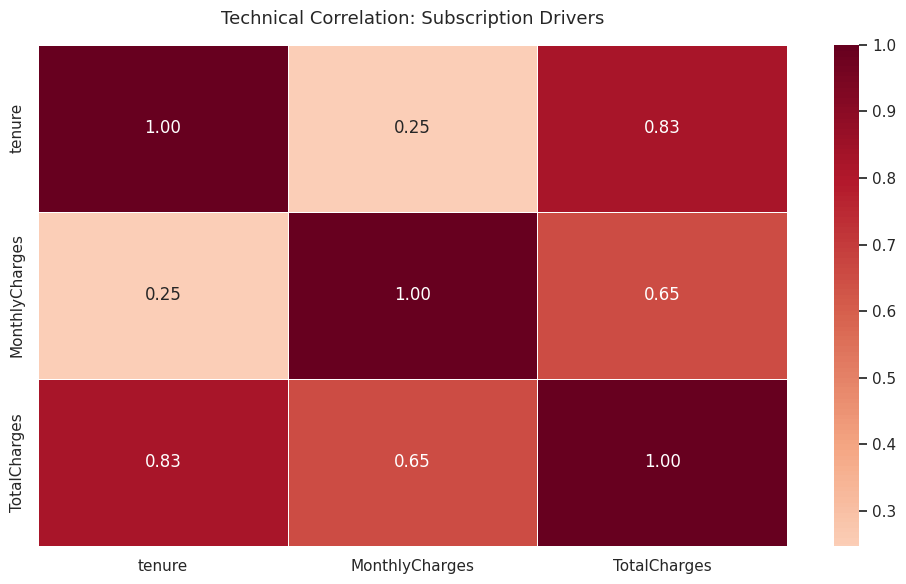

In [ ]:
# =============================================================
# TECHNICAL VALIDATION: DATA CORRELATIONS
# =============================================================

plt.figure(figsize=(10, 6))
sns.set_theme(style="white")

# Identifying relationships between key numeric KPIs
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr_matrix = fact_subscription[numeric_cols].corr()

# Plotting the heatmap with a diverging color palette
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)

plt.title('Technical Correlation: Subscription Drivers', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

### Insight — Structural Revenue Drivers

Tenure and TotalCharges show a strong correlation, confirming that **customer lifetime — not pricing — is the dominant driver of cumulative revenue**.

MonthlyCharges exhibit only moderate correlation with TotalCharges, indicating that **high bills alone do not guarantee high lifetime value** without retention longevity.

📌 This validates **tenure-based and lifecycle-aware retention strategies** over price-only targeting.

## Business Intelligence & EDA

**Business Question: Is our revenue loss concentrated in a specific customer lifecycle or contract type?**

**Analytical Goals:**

* Quantify the "Churn Funnel" across the customer lifecycle.

* Identify the highest-exposure contract segments.

In [ ]:
# =============================================================
# BUSINESS INTELLIGENCE & EDA
# =============================================================

# We utilize the Dataframes currently in memory to maintain Data Lineage.
# This approach ensures that all upstream ETL fixes are preserved and
# avoids the performance overhead of redundant I/O operations.

# 1. Analytical Environment Initialization
print("--- Environment Status: Ready for Analysis ---")
print(f"✅ Master Fact Records: {len(fact_subscription):,}")
print(f"✅ Feedback Records:    {len(fact_feedback):,}")

# 2. Final Data Model Verification
# Previewing the Subscription Fact table as the primary source for EDA
display(fact_subscription.head())

--- Environment Status: Ready for Analysis ---
✅ Master Fact Records: 7,043
✅ Feedback Records:    2,224


,customerID,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Univariate Analysis
We examine distributions of tenure and monthly charges.

**Numeric Distribution Audit**

In [ ]:
# =============================================================
# UNIVARIATE ANALYSIS: KEY METRIC DISTRIBUTIONS
# =============================================================

# Generating descriptive statistics for strategic KPIs
# This defines the 'Normal' customer range for tenure and monthly revenue
stats = fact_subscription[["tenure", "MonthlyCharges"]].describe().round(2)

print("--- Key Metric Distributions ---")
display(stats)

--- Key Metric Distributions ---


,tenure,MonthlyCharges
count,7043.00,7043.00
mean,32.37,64.76
std,24.56,30.09
min,0.00,18.25
25%,9.00,35.50
50%,29.00,70.35
75%,55.00,89.85
max,72.00,118.75


## Bivariate Analysis
We analyze churn by contract type and tenure.

**Contract Impact Analysis**

In [ ]:
# =============================================================
# BIVARIATE ANALYSIS: CONTRACT STRATEGY IMPACT
# =============================================================

# Calculating churn probability by contract type
# 'normalize=True' converts raw counts into a 0.0 - 1.0 probability range
contract_churn = (
    fact_subscription
    .groupby("Contract")["Churn"]
    .value_counts(normalize=True)
    .unstack()
    .round(4) * 100
)

print("--- Churn Probability by Contract Type (%) ---")
display(contract_churn)

--- Churn Probability by Contract Type (%) ---


Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


## LIFECYCLE RISK FUNNEL (RULE-BASED)

This phase translates churn from a binary outcome into a **progressive lifecycle risk model** to support targeted retention actions.

## Customer Lifecycle Segmentation
**Purpose:** We bucket tenure into 5 strategic groups (0-72 months). This allows the business to see if churn is an "Onboarding" problem or a "Loyalty" problem.

In [ ]:
# =============================================================
# STRATEGIC SEGMENTATION: DEFINING THE LIFECYCLE GROUPS
# =============================================================

# 1. Define logical bins for customer lifetime (in months)
tenure_bins = [0, 6, 12, 24, 48, 72]
tenure_labels = ["0–6", "7–12", "13–24", "25–48", "49–72"]

# 2. Segment customers into these groups
fact_subscription["tenure_group"] = pd.cut(
    fact_subscription["tenure"],
    bins=tenure_bins,
    labels=tenure_labels,
    include_lowest=True
)

# 3. Create a Single Summary Table (The "Master Funnel")
# We use named aggregation here: (target_column, function)
lifecycle_summary = (
    fact_subscription
    .groupby("tenure_group", observed=False)
    .agg(
        customer_count=('customerID', 'count'),
        churn_rate=('Churn', lambda x: (x == "Yes").mean() * 100)
    )
    .reset_index()
)

# 4. Clean up column names for presentation
lifecycle_summary.columns = ["Tenure Group (Months)", "Total Customers (N)", "Churn Rate (%)"]

print("--- Phase 5: Customer Lifecycle Funnel ---")
display(lifecycle_summary.round(2))

--- Phase 5: Customer Lifecycle Funnel ---


,Tenure Group (Months),Total Customers (N),Churn Rate (%)
0,0–6,1481,52.94
1,7–12,705,35.89
2,13–24,1024,28.71
3,25–48,1594,20.39
4,49–72,2239,9.51


### Insight — Early Lifecycle Failure

**Over 52% of churn occurs in the first 6 months.**
> **Strategic Impact:** This is a failure in the onboarding experience, not product quality. Retention investment should be front-loaded into the first 180 days to maximize Customer Lifetime Value (CLV).

**The "Friction Point" Topography**

**Objective:** Correlate quantitative churn with qualitative complaints.

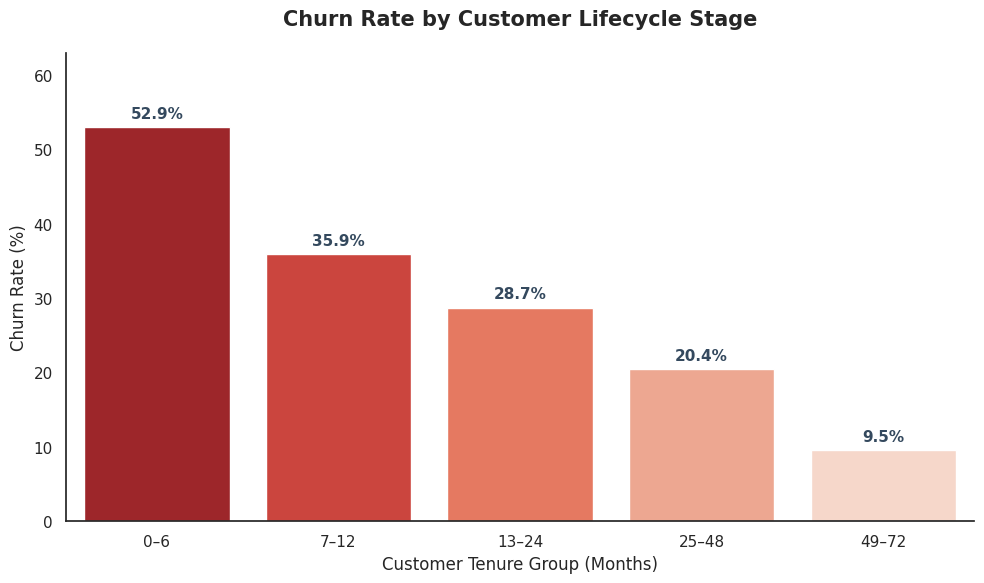

In [ ]:
# =============================================================
# VISUAL ANALYSIS: CHURN FRICTION TOPOGRAPHY
# =============================================================

# 1. Visualization Setup
sns.set_theme(style="white")
plt.figure(figsize=(10, 6))

# 2. Bar Plot Generation
# We utilize the 'lifecycle_summary' created in the previous step
ax = sns.barplot(
    x="Tenure Group (Months)",
    y="Churn Rate (%)",
    data=lifecycle_summary,
    hue="Tenure Group (Months)",
    palette="Reds_r",
    legend=False
)

# 3. Aesthetics & Labeling
plt.title("Churn Rate by Customer Lifecycle Stage", fontsize=15, pad=20, fontweight='bold')
plt.xlabel("Customer Tenure Group (Months)", fontsize=12)
plt.ylabel("Churn Rate (%)", fontsize=12)
plt.ylim(0, lifecycle_summary["Churn Rate (%)"].max() + 10) # Dynamic headroom for labels

# 4. Data Annotation: Overlaying percentages for immediate insight
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:.1f}%',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='center',
        xytext=(0, 10),
        textcoords='offset points',
        fontsize=11,
        fontweight='bold',
        color='#34495e'
    )

sns.despine() # Removes top and right borders for a cleaner, modern look
plt.tight_layout()
plt.show()

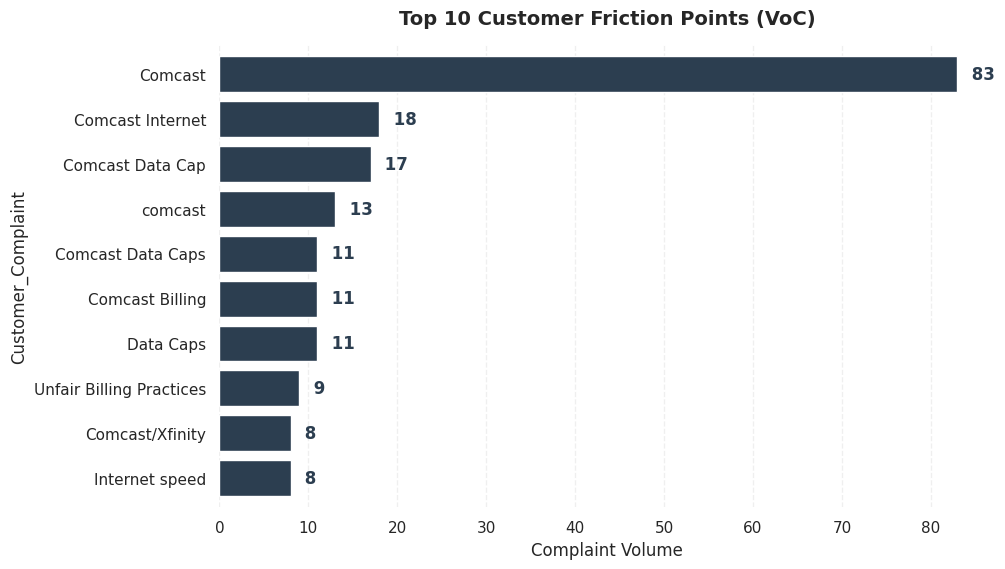

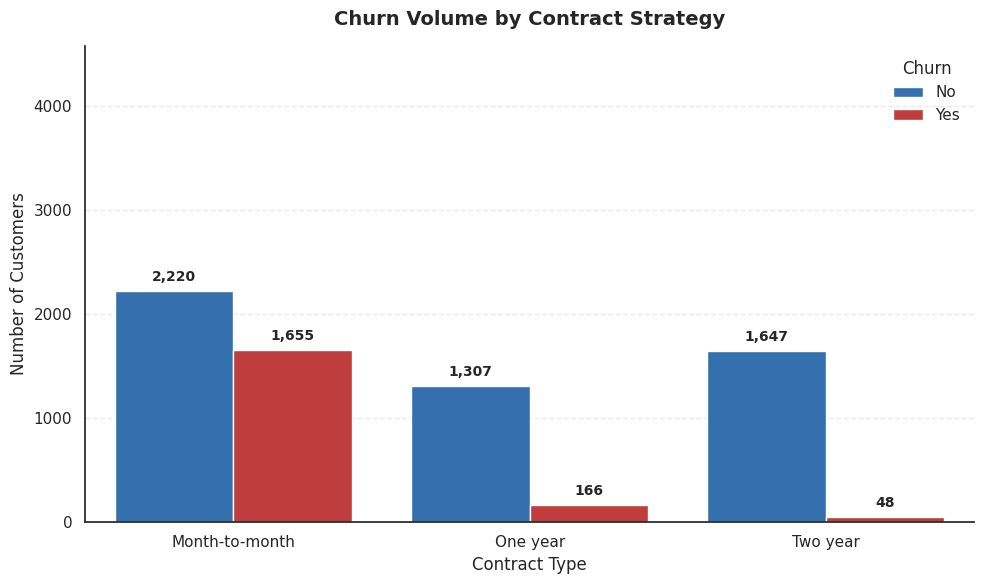

In [ ]:
# =============================================================
# STRATEGIC INSIGHT: SENTIMENT & CONTRACT RISK
# =============================================================

# --- VISUAL 01: COMPLAINT TOPOGRAPHY (VoC ANALYSIS) ---
plt.figure(figsize=(10, 6))
top_complaints = fact_feedback['Customer_Complaint'].value_counts().head(10)

# Horizontal orientation optimized for categorical text readability
ax1 = top_complaints.plot(kind='barh', color='#2c3e50', width=0.8)
plt.gca().invert_yaxis() # Prioritize highest volume at the top

# Data Annotation: Value labels for precise volume tracking
for i, v in enumerate(top_complaints):
    ax1.text(v + 1, i, f" {v}", color='#2c3e50', va='center', fontweight='bold')

plt.title('Top 10 Customer Friction Points (VoC)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Complaint Volume')
plt.grid(axis='x', linestyle='--', alpha=0.3, zorder=0)
sns.despine(left=True, bottom=True)
plt.show()

# --- VISUAL 02: CONTRACT STRATEGY IMPACT (REVENUE RISK) ---
plt.figure(figsize=(10, 6))

# Mapping sentiment colors: Retention (Blue) vs. Attrition (Red)
ax2 = sns.countplot(
    data=fact_subscription,
    x='Contract',
    hue='Churn',
    palette=['#1F70C1', '#D62728']
)

# Data Annotation: Volume labels with standard thousands separator
for p in ax2.patches:
    if p.get_height() > 0:
        ax2.annotate(
            f'{int(p.get_height()):,}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='center',
            xytext=(0, 10),
            textcoords='offset points',
            fontsize=10,
            fontweight='bold'
        )

# Aesthetic Refinement: Horizontal gridlines for executive readability
# We use a low alpha to keep the focus on the data bars
plt.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
ax2.set_axisbelow(True) # Ensures gridlines sit behind the bars

plt.title('Churn Volume by Contract Strategy', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Number of Customers')
plt.xlabel('Contract Type')
plt.ylim(0, fact_subscription['Contract'].value_counts().max() + 700)

sns.despine()
plt.tight_layout()
plt.show()

### Insight — Structural Churn Risk Concentration

Month-to-month contracts account for the **largest volume of churn**, while customer complaints cluster around **internet service reliability and billing practices**.

📌 Retention impact is highest when **contract strategy and service quality are addressed together**, not independently.

## REVENUE AT RISK QUANTIFICATION

This phase translates churn behavior into **explicit financial exposure**, prioritizing actions based on revenue at risk rather than customer count.

### Statistical Validation & Anomaly Detection
**Business Question: Are there extreme billing outliers that could skew our revenue projections or indicate data entry errors?**

**Methodology:** We apply the Interquartile Range (IQR) Method to audit MonthlyCharges.

**Decision Framework:** Outliers are not automatically deleted. In a subscription business, high-revenue "Whales" are valid and critical to retention strategy. We audit to ensure no values are mathematically impossible.

In [ ]:
# =============================================================
# STATISTICAL VALIDATION: OUTLIER AUDIT (IQR METHOD)
# =============================================================

# 1. Define Interquartile Range (IQR) for Monthly Charges
q1 = fact_subscription["MonthlyCharges"].quantile(0.25)
q3 = fact_subscription["MonthlyCharges"].quantile(0.75)
iqr = q3 - q1

# 2. Define standard statistical boundaries (1.5x IQR rule)
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# 3. Audit for revenue anomalies
outliers = fact_subscription[
    (fact_subscription["MonthlyCharges"] < lower_bound) |
    (fact_subscription["MonthlyCharges"] > upper_bound)
]

print("--- Revenue Integrity Audit ---")
print(f"✅ Lower Bound: ${lower_bound:.2f} | Upper Bound: ${upper_bound:.2f}")
print(f"✅ Total Anomalies Detected: {len(outliers)}")

# Display results if anomalies are found
if not outliers.empty:
    display(outliers.head())

--- Revenue Integrity Audit ---
✅ Lower Bound: $-46.02 | Upper Bound: $171.38
✅ Total Anomalies Detected: 0


### Insight - Anomaly Detection
Zero statistical outliers were found in the revenue data. This confirms that our "Premium" tier (~$118/mo) is within a **valid business range**, ensuring our "Revenue at Risk" totals are **not inflated by data errors**.

## Developing the "Revenue at Risk" Framework

**Business Question:**  
How do we quantify *preventable financial exposure* without corrupting lifecycle logic?

### Conceptual Model

This project **explicitly separates two dimensions**:

1. **Lifecycle Status (Mutually Exclusive, Funnel-Safe)**
   - `Active`
   - `Churned`

2. **Risk Segmentation (Subset of Active Customers)**
   - `Low Risk`
   - `Medium Risk`
   - `High Risk`

📌 **Critical Governance Rule:**  
“At-Risk” is **not** a lifecycle stage.  
It is a **risk segmentation of active customers**.

This prevents:
- Funnel inversion in Power BI
- Double-counting of customers
- Misinterpretation of retention opportunity

---

### Risk Signals Used (Rule-Based Layer)

Risk exposure is evaluated using **three operational signals**:

- **Contract Risk:** Month-to-month contract
- **Lifecycle Risk:** Tenure ≤ 12 months (onboarding vulnerability)
- **Financial Risk:** Top 25% of Monthly Charges (“Revenue Concentration”)

These signals are used to **prioritize retention**, not to redefine lifecycle state.

In [ ]:
# =============================================================
# RISK MODELING: PREMIUM SEGMENT IDENTIFICATION
# =============================================================

# Define 'High Charge' threshold as the Top 25% of spenders (75th Percentile)
# Identifying 'Premium' customers is critical for prioritizing retention ROI.
high_charge_threshold = fact_subscription["MonthlyCharges"].quantile(0.75)

print(f"--- Segment Definitions ---")
print(f"✅ High-Value Customer Threshold: ${high_charge_threshold:.2f}/month")

--- Segment Definitions ---
✅ High-Value Customer Threshold: $89.85/month


In [ ]:
# =============================================================
# RISK PENETRATION: MULTI-FACTOR AUDIT
# =============================================================

# Create a dedicated dataframe for funnel stage modeling
funnel_df = fact_subscription.copy()

# Assign binary risk flags based on strategic business logic
funnel_df["risk_month_to_month"] = (funnel_df["Contract"] == "Month-to-month")
funnel_df["risk_short_tenure"] = (funnel_df["tenure"] <= 12)
funnel_df["risk_high_charges"] = (funnel_df["MonthlyCharges"] >= high_charge_threshold)

print("--- Portfolio Risk Penetration (%) ---")
risk_metrics = funnel_df[["risk_month_to_month", "risk_short_tenure", "risk_high_charges"]].mean() * 100
print(risk_metrics.round(2))

--- Portfolio Risk Penetration (%) ---
risk_month_to_month    55.02
risk_short_tenure      31.04
risk_high_charges      25.15
dtype: float64


In [ ]:
# =============================================================================
# ARCHITECTURAL LOGIC — LIFECYCLE & RISK DECOUPLING
# =============================================================================

funnel_df = fact_subscription.copy()

# 1. LIFECYCLE STAGE (Binary Status)
# Preserving the raw split between current and lost customers
funnel_df["lifecycle_stage"] = np.where(
    funnel_df["Churn"] == "Yes",
    "Churned",
    "Active"
)

# 2. RISK SIGNAL FLAGS (Atomic & Explainable)
# We use boolean flags to make the risk model interpretable for stakeholders
funnel_df["risk_month_to_month"] = funnel_df["Contract"] == "Month-to-month"
funnel_df["risk_short_tenure"] = funnel_df["tenure"] <= 12

# Defining high charges based on the 75th percentile (Data-Driven Threshold)
high_charge_threshold = funnel_df["MonthlyCharges"].quantile(0.75)
funnel_df["risk_high_charges"] = funnel_df["MonthlyCharges"] >= high_charge_threshold

# Aggregating signals into a single count
funnel_df["risk_signal_count"] = (
    funnel_df["risk_month_to_month"].astype(int) +
    funnel_df["risk_short_tenure"].astype(int) +
    funnel_df["risk_high_charges"].astype(int)
)

# 3. RISK LEVEL ASSIGNMENT
def assign_risk_level(row):
    """Categorizes customers based on lifecycle status and risk flags."""
    if row["lifecycle_stage"] == "Churned":
        return "Churned"
    if row["risk_signal_count"] == 0:
        return "Low Risk"
    elif row["risk_signal_count"] == 1:
        return "Medium Risk"
    else:
        return "High Risk"

funnel_df["Risk_Level_Rule_Based"] = funnel_df.apply(assign_risk_level, axis=1)

# 4. ENFORCING CATEGORICAL ORDER
# Essential for consistent visualization in Power BI and Seaborn
risk_order = ["Low Risk", "Medium Risk", "High Risk", "Churned"]
funnel_df["Risk_Level_Rule_Based"] = pd.Categorical(
    funnel_df["Risk_Level_Rule_Based"],
    categories=risk_order,
    ordered=True
)

# 5. VALIDATION OUTPUT
print("=== Lifecycle Distribution ===")
print(funnel_df["lifecycle_stage"].value_counts())

print("\n=== Risk Distribution (Governed & Ordered) ===")
print(funnel_df["Risk_Level_Rule_Based"].value_counts().sort_index())

display(funnel_df[[
    "customerID", "Contract", "tenure", "MonthlyCharges",
    "risk_signal_count", "lifecycle_stage", "Risk_Level_Rule_Based"
]].head(10))

=== Lifecycle Distribution ===
lifecycle_stage
Active     5174
Churned    1869
Name: count, dtype: int64

=== Risk Distribution (Governed & Ordered) ===
Risk_Level_Rule_Based
Low Risk       2009
Medium Risk    1821
High Risk      1344
Churned        1869
Name: count, dtype: int64


,customerID,Contract,tenure,MonthlyCharges,risk_signal_count,lifecycle_stage,Risk_Level_Rule_Based
0,7590-VHVEG,Month-to-month,1,29.85,2,Active,High Risk
1,5575-GNVDE,One year,34,56.95,0,Active,Low Risk
2,3668-QPYBK,Month-to-month,2,53.85,2,Churned,Churned
3,7795-CFOCW,One year,45,42.30,0,Active,Low Risk
4,9237-HQITU,Month-to-month,2,70.70,2,Churned,Churned
5,9305-CDSKC,Month-to-month,8,99.65,3,Churned,Churned
6,1452-KIOVK,Month-to-month,22,89.10,1,Active,Medium Risk
7,6713-OKOMC,Month-to-month,10,29.75,2,Active,High Risk
8,7892-POOKP,Month-to-month,28,104.80,2,Churned,Churned
9,6388-TABGU,One year,62,56.15,0,Active,Low Risk


**Quantifying the Financial Exposure**

**Goal:** Assign a dollar value to the "At-Risk" segment to prioritize executive intervention.

In [ ]:
# =============================================================================
# FINANCIAL QUANTIFICATION — REVENUE EXPOSURE SUMMARY
# =============================================================================

# 1. FILTERING FOR ACTIONABLE INSIGHTS
# We isolate the 'Active' portfolio to quantify preventable revenue loss
active_portfolio = funnel_df[funnel_df["lifecycle_stage"] == "Active"].copy()

# 2. STRATEGIC AGGREGATION
# observed=True ensures we don't calculate stats for the 'Churned' category
revenue_summary = (
    active_portfolio
    .groupby("Risk_Level_Rule_Based", observed=True)
    .agg(
        customers=("customerID", "count"),
        avg_monthly_rev=("MonthlyCharges", "mean"),
        total_monthly_rev=("MonthlyCharges", "sum")
    )
    .reset_index()
)

# 3. REVENUE WEIGHTING
# Calculating the percentage of total monthly revenue at stake per tier
total_rev = revenue_summary["total_monthly_rev"].sum()
revenue_summary["revenue_share_pct"] = (
    revenue_summary["total_monthly_rev"] / total_rev * 100
)

# 4. PRESENTATION REFINEMENT
# Renaming columns for business-ready reporting
revenue_summary.columns = [
    "Risk Level",
    "Customer Count (N)",
    "Avg Revenue ($)",
    "Total Revenue ($)",
    "Revenue Share (%)"
]

print("--- Executive Revenue at Risk (Active Portfolio Only) ---")
display(revenue_summary.round(2))

--- Executive Revenue at Risk (Active Portfolio Only) ---


,Risk Level,Customer Count (N),Avg Revenue ($),Total Revenue ($),Revenue Share (%)
0,Low Risk,2009,47.58,95582.20,30.15
1,Medium Risk,1821,75.07,136697.30,43.12
2,High Risk,1344,63.03,84706.25,26.72


### Insight — Financial Exposure (Rule-Based Risk Funnel)

Active customers with elevated churn signals represent the **largest preventable revenue exposure**.

**Key Insight:**  
Among **5,174 active customers**, the **Medium-Risk segment (1,821 customers)** accounts for the **largest share of revenue at risk (43%)**, exceeding both Low-Risk (30%) and High-Risk (27%) groups.

**Strategic Impact:**  
Although High-Risk customers signal urgency, **Medium-Risk customers offer the highest retention ROI**:
- They remain behaviorally engaged
- They concentrate the largest revenue share
- They can be stabilized before escalating to high-risk or churn

📌 **Executive Takeaway:**  
Revenue protection is maximized by **intervening during medium-risk stages**, not by reacting after customers reach high-risk or churn.

## PREDICTIVE RISK SCORING (DECISION SUPPORT)

This phase represents the **final decision-support layer** of the analytics process.
All prior phases establish *what is happening* and *where revenue is at risk*;
machine learning is introduced **only at this stage** to prioritize action,
not to redefine business logic or infer causality.

Machine learning is used strictly to **rank and prioritize customers**, not to automate decisions or replace operational judgment.

## Predictive Modeling for Retention Prioritization

**Business Question:**  
Can we use machine learning to move from reactive churn reporting to **proactive customer risk prioritization**?

**Model Objective:**  
Use **Logistic Regression** to assign a **Churn Probability Score (0.0–1.0)** to every active customer, enabling tiered retention actions.

**Hiring Manager Note:**  
This model is designed for **decision support**, not automation.  
We prioritize **interpretability and business control** over marginal gains in black-box accuracy.

In [ ]:
# =============================================================
# OPTIMIZED PREDICTIVE MODELING (SCALED PIPELINE)
# =============================================================

# 1. Feature Selection & Target Mapping
# We isolate high-impact variables and map Churn to a binary numeric format
y = fact_subscription["Churn"].map({"Yes": 1, "No": 0})
X = fact_subscription[["tenure", "MonthlyCharges", "Contract", "InternetService", "PaymentMethod"]]

# 2. Advanced Preprocessing Architecture
# Standardizing numeric scales and encoding categories in a single pass
categorical_features = ["Contract", "InternetService", "PaymentMethod"]
numeric_features = ["tenure", "MonthlyCharges"]

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(drop="first"), categorical_features),
    ("num", StandardScaler(), numeric_features)
])

# 3. Model Pipeline Construction
# We use 'balanced' class weights to optimize for Churn detection (Class 1)
model_pipeline = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# 4. Stratified Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 5. Model Training & Multi-Metric Evaluation
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)
y_prob = model_pipeline.predict_proba(X_test)[:, 1]

# 6. Final Performance Audit
print("--- MODEL PERFORMANCE METRICS ---")
print(f"✅ Model Discriminative Power (AUC): {roc_auc_score(y_test, y_prob):.3f}")
print("\nDetailed Classification Report:")
print("-" * 55)
print(classification_report(y_test, y_pred))
print("-" * 55)

--- MODEL PERFORMANCE METRICS ---
✅ Model Discriminative Power (AUC): 0.836

Detailed Classification Report:
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1552
           1       0.50      0.80      0.62       561

    accuracy                           0.74      2113
   macro avg       0.71      0.76      0.71      2113
weighted avg       0.80      0.74      0.75      2113

-------------------------------------------------------


### Insight — Predictive Modeling (Decision Support)

**Model Performance Summary:**  
The model achieved an **AUC of 0.836**, confirming strong overall discriminative power between churners and non-churners.

By applying **Balanced Class Weights**, the model intentionally prioritizes **Recall (0.80)** for churn detection over precision.

**Strategic Trade-Off (Explicit):**  
- ✅ **80% of actual churners are correctly identified**  
- ⚠️ Increased false positives are accepted as a **controlled operational cost**

In a retention context, **missed churners (false negatives) represent guaranteed revenue loss**, while proactive outreach to some low-risk customers is comparatively inexpensive.

**Operational Action — Tiered Retention Strategy:**
- **Tier 1 (Churn Probability > 0.80):**  
  Immediate high-touch outreach, personalized offers, or contract conversion incentives.
- **Tier 2 (Churn Probability 0.60–0.80):**  
  Automated onboarding reinforcement, feature education, and service reassurance campaigns.

📌 **Business Rationale:**  
This model is optimized to **minimize preventable revenue loss**, not to maximize prediction purity. It functions as a **risk radar**, not a churn verdict engine.

## Data Harmonization & Executive Synthesis
**Business Question: How do we translate complex model outputs into actionable geographic and financial insights for stakeholders?**

**Final ETL Steps:**

* Probability Sync: Mapping ML scores back to the core data model.

* VoC Refinement: Standardizing qualitative complaints (e.g., merging "Data Caps" and "Internet Speeds") for clearer dashboard reporting.

* Geographic Mapping: Identifying friction hotspots (Georgia/Florida).

📌 Complaint insights are interpreted as **directional friction signals**, not causal churn drivers.

In [ ]:
# =============================================================================
# DATA ENRICHMENT & UNIFIED EXPORT (SINGLE SOURCE OF TRUTH)
# =============================================================================


# 1. INITIALIZE ENRICHED DATAFRAME
fact_subscription_enriched = fact_subscription.copy()

# 2. INTEGRATE ML PROBABILITIES
# Generating churn probabilities from the trained model pipeline
fact_subscription_enriched["Churn_Probability"] = model_pipeline.predict_proba(X)[:, 1]

# 3. GOVERNED LIFECYCLE CLASSIFICATION
# Decoupling current status (Active/Churned) from future risk
fact_subscription_enriched["lifecycle_stage"] = np.where(
    fact_subscription_enriched["Churn"] == "Yes",
    "Churned",
    "Active"
)

# 4. RULE-BASED RISK SIGNAL ENGINEERING
# Applying the architectural logic defined in Step 8
high_charge_threshold = fact_subscription_enriched["MonthlyCharges"].quantile(0.75)

fact_subscription_enriched["risk_signal_count"] = (
    (fact_subscription_enriched["Contract"] == "Month-to-month").astype(int) +
    (fact_subscription_enriched["tenure"] <= 12).astype(int) +
    (fact_subscription_enriched["MonthlyCharges"] >= high_charge_threshold).astype(int)
)

# 5. UNIFIED RISK STRATIFICATION
def assign_governed_risk(row):
    """Assigns final risk tiers based on lifecycle and risk signals."""
    if row["lifecycle_stage"] == "Churned":
        return "Churned"
    if row["risk_signal_count"] == 0:
        return "Low Risk"
    elif row["risk_signal_count"] == 1:
        return "Medium Risk"
    else:
        return "High Risk"

fact_subscription_enriched["Risk_Level"] = fact_subscription_enriched.apply(
    assign_governed_risk, axis=1
)

# 6. ENFORCING CATEGORICAL INTEGRITY
risk_order = ["Low Risk", "Medium Risk", "High Risk", "Churned"]
fact_subscription_enriched["Risk_Level"] = pd.Categorical(
    fact_subscription_enriched["Risk_Level"],
    categories=risk_order,
    ordered=True
)

# 7. EXPORT FOR DOWNSTREAM SYSTEMS (SQL & POWER BI)
fact_subscription_enriched.to_csv("fact_subscription.csv", index=False)

print("--- Production Data Enrichment Complete ---")
print(f"✅ Records Enriched: {len(fact_subscription_enriched)}")
print(fact_subscription_enriched["Risk_Level"].value_counts().sort_index())

--- Production Data Enrichment Complete ---
✅ Records Enriched: 7043
Risk_Level
Low Risk       2009
Medium Risk    1821
High Risk      1344
Churned        1869
Name: count, dtype: int64


In [ ]:
# =============================================================
# INSIGHT REFINEMENT: QUALITATIVE DATA STANDARDIZATION
# =============================================================

# 1. Financial Exposure Audit
# Quantifying the exact monthly revenue tied to the 'High Risk' ML segment
at_risk_revenue = fact_subscription_enriched[
    fact_subscription_enriched['Risk_Level'] == 'High Risk'
]['MonthlyCharges'].sum()

# 2. Geographic Friction Analysis
top_states = fact_feedback['State'].value_counts()

# 3. NLP Preprocessing: Text Normalization
# Converting to lowercase to ensure consistency across the complaint dataset
fact_feedback['Clean_Complaint'] = fact_feedback['Customer_Complaint'].str.lower()

# 4. Heuristic-Based Categorization
# This logic groups disparate text strings into standardized business categories
category_map = {
    'data cap': 'Data Caps & Overages',
    'internet': 'Internet Service Quality',
    'billing': 'Billing & Payment Issues',
    'speed': 'Internet Service Quality'
}

# Standardizing text using a vectorized-style approach for performance
for key, value in category_map.items():
    fact_feedback.loc[fact_feedback['Clean_Complaint'].str.contains(key), 'Clean_Complaint'] = value

# 5. Executive Summary Generation
top_issues = fact_feedback['Clean_Complaint'].value_counts().head(5)

print("--- REFINED STRATEGIC INSIGHTS ---")
print(f"Total Revenue At-Risk (Monthly): ${at_risk_revenue:,.2f}")
print(f"Key Geographic Friction Zones:   {top_states.index[0]}, {top_states.index[1]}")

print("\n--- STANDARDIZED TOP COMPLAINTS (Normalized) ---")
print(top_issues)

--- REFINED STRATEGIC INSIGHTS ---
Total Revenue At-Risk (Monthly): $84,706.25
Key Geographic Friction Zones:   Georgia, Florida

--- STANDARDIZED TOP COMPLAINTS (Normalized) ---
Clean_Complaint
Internet Service Quality    599
Billing & Payment Issues    263
Data Caps & Overages        150
comcast                     102
comcast service              15
Name: count, dtype: int64


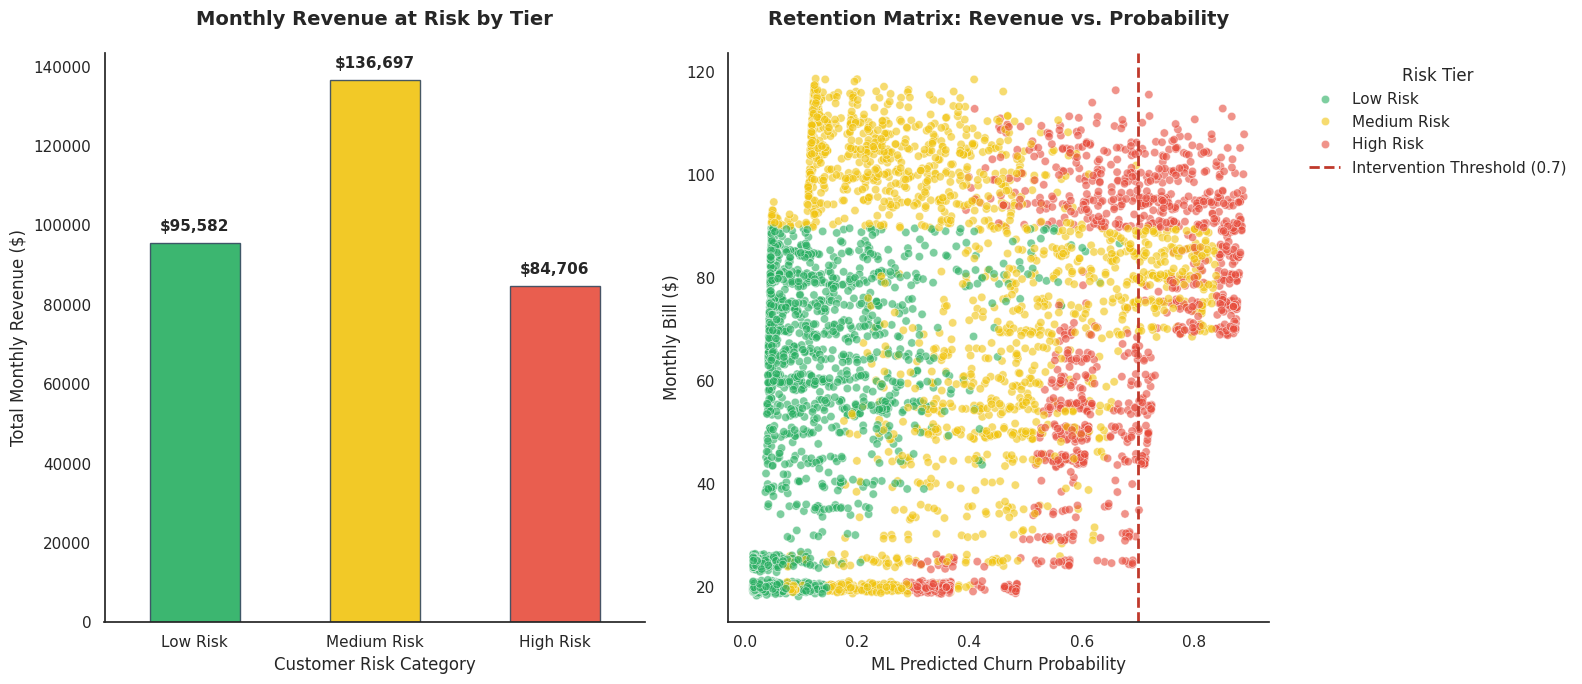

In [ ]:
# =============================================================================
# EXECUTIVE DASHBOARD — FINANCIAL IMPACT & RETENTION STRATEGY
# =============================================================================

# 1. VISUAL CONFIGURATION
risk_order = ["Low Risk", "Medium Risk", "High Risk"]
brand_colors = ["#27ae60", "#f1c40f", "#e74c3c"]  # Success Green, Gold, Red

# 2. DATA SYNCHRONIZATION
# We isolate the 'Active' portfolio from our Single Source of Truth (SSOT).
# This ensures the dashboard reflects actionable revenue opportunity.
active_retention_data = fact_subscription_enriched[
    fact_subscription_enriched["lifecycle_stage"] == "Active"
].copy()

# 3. DASHBOARD INITIALIZATION
plt.figure(figsize=(16, 7))

# --- VISUAL 01: REVENUE AT RISK (AGGREGATED EXPOSURE) ---
plt.subplot(1, 2, 1)

# Aggregating total monthly revenue exposure per risk segment
risk_revenue = (
    active_retention_data
    .groupby("Risk_Level", observed=True)["MonthlyCharges"]
    .sum()
    .reindex(risk_order)
)

ax1 = risk_revenue.plot(
    kind="bar",
    color=brand_colors,
    edgecolor="#34495e",
    alpha=0.9
)

# Professional Data Annotation: Dynamic currency formatting
for p in ax1.patches:
    val = p.get_height()
    if val > 0:
        ax1.annotate(
            f"${val:,.0f}",
            (p.get_x() + p.get_width() / 2., val),
            ha="center",
            va="center",
            xytext=(0, 12),
            textcoords="offset points",
            fontsize=11,
            fontweight="bold"
        )

plt.title("Monthly Revenue at Risk by Tier", fontsize=14, fontweight="bold", pad=20)
plt.ylabel("Total Monthly Revenue ($)", fontsize=12)
plt.xlabel("Customer Risk Category", fontsize=12)
plt.xticks(rotation=0)
sns.despine()

# --- VISUAL 02: TARGETING MAP (GRANULAR INTERVENTION) ---
plt.subplot(1, 2, 2)

# Scatter plot to identify individual high-value/high-probability targets
sns.scatterplot(
    data=active_retention_data,
    x="Churn_Probability",
    y="MonthlyCharges",
    hue="Risk_Level",
    palette=brand_colors,
    hue_order=risk_order,
    alpha=0.6,
    edgecolor="w"
)

# Strategic Intervention Threshold: Defined at 0.7 probability
plt.axvline(
    x=0.7,
    color="#c0392b",
    linestyle="--",
    linewidth=2,
    label="Intervention Threshold (0.7)"
)

plt.title("Retention Matrix: Revenue vs. Probability", fontsize=14, fontweight="bold", pad=20)
plt.xlabel("ML Predicted Churn Probability", fontsize=12)
plt.ylabel("Monthly Bill ($)", fontsize=12)
plt.legend(title="Risk Tier", bbox_to_anchor=(1.05, 1), loc="upper left")

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================
# FINAL MASTER EXPORT & WORKSPACE CLEANUP
# =============================================================

# 1. Export ALL final analytics tables
# We include the Dimension table and the enriched Fact tables
dim_customer.to_csv('dim_customer.csv', index=False)
fact_subscription_enriched.to_csv('fact_subscription.csv', index=False)
fact_feedback.to_csv('fact_feedback.csv', index=False)

print("✅ All analytics tables (Dimension & Facts) exported successfully.")

# 2. Trigger Automatic Downloads for the full dataset
# This loop now includes all three files for a seamless transfer to SQL/Power BI
# Ensure EXPORT_FILES at the top of your notebook includes 'dim_customer.csv'
ALL_FINAL_FILES = ['dim_customer.csv', 'fact_subscription.csv', 'fact_feedback.csv']

for file_path in ALL_FINAL_FILES:
    try:
        files.download(file_path)
    except Exception as e:
        print(f"Download prompt triggered for {file_path}")

# 3. Memory Management: Workspace Cleanup
# We use a try-except block so the code doesn't crash if these are already deleted
try:
    del X_train, X_test, funnel_df
    gc.collect()
    print("🚀 Environment Cleaned.")
except NameError:
    print("🚀 Environment already clean.")

✅ All analytics tables (Dimension & Facts) exported successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

🚀 Environment Cleaned.


## EXECUTIVE SYNTHESIS & DELIVERY

### Executive Summary — Retention Opportunity

- **High-Risk customers account for ~$84,706 in monthly revenue exposure**
- Revenue risk is concentrated among **high-bill customers with elevated churn probability**
- **Early-tenure customers (≤12 months)** represent the most cost-effective intervention window

📌 **Retention Priorities:**  
Focus investment on:
1. Month-to-month customers within their first 12 months  
2. Customers with **churn probability > 0.70** and above-average monthly charges  
3. Service quality improvements targeting **Internet reliability** and **Billing clarity**

## Final Conclusion — Revenue Protection Through Early Risk Intervention

This analysis demonstrates that the **largest retention opportunity exists before customers reach high-risk or churn states**.

After decoupling lifecycle status from churn risk:
- **5,174 customers** remain active and eligible for retention
- **1,869 customers** are churned and represent realized (non-recoverable) loss

By separating lifecycle status from forward-looking risk, revenue-at-risk now reflects actionable opportunity rather than historical loss.

### Revenue-at-Risk Breakdown (Active Customers Only)
- **Medium Risk:** 1,821 customers → **\$136.7K/month (43%)**
- **Low Risk:** 2,009 customers → **\$95.6K/month (30%)**
- **High Risk:** 1,344 customers → **\$84.7K/month (27%)**

### Key Insight
Although high-risk customers signal urgency, **medium-risk customers concentrate the largest share of preventable revenue exposure**.  
In practice, high-risk customers require immediate tactical intervention, while medium-risk customers represent the strategic investment opportunity for revenue protection.  
They remain behaviorally engaged, have not yet disengaged operationally, and therefore offer the **highest retention ROI**.

### Executive Implications
Effective retention strategy should:
- Prioritize **medium-risk customers**
- Intervene during **early-to-mid tenure**
- Focus on **revenue stabilization before escalation**

### Bottom Line
Retention value is maximized by **acting earlier in the risk curve**, not by reacting after customers reach critical risk or churn.  
The greatest impact comes from stabilizing customers **before churn becomes imminent**, not after it is inevitable.
